In [220]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot
import torch
from torch import nn, optim
import pathlib
#https://link.springer.com/content/pdf/10.1007/978-981-96-7005-5.pdf

In [221]:
from torch.utils.data import TensorDataset, DataLoader
with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    features_unnormalized = torch.tensor(pd.DataFrame(training_data_FD).values)
    # training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))    

# hls4ml_lhc_jets_hlf = pd.read_parquet("data/hls4ml_lhc_jets_hlf.parquet")
# features_unnormalized = torch.tensor(
#     hls4ml_lhc_jets_hlf.drop("jet_type", axis=1).values, dtype=torch.float32
# )
features = (features_unnormalized - features_unnormalized.mean(axis=0)) / features_unnormalized.std(axis=0)
dataset = TensorDataset(features)     # No labels
loader = DataLoader(dataset, batch_size=2000, shuffle=True)

print(features.shape)

with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg_df = pd.DataFrame(training_data_bkg).iloc[:10000]
    test_features_unnormalized = torch.tensor(training_data_bkg_df.values)
features_test = (test_features_unnormalized - test_features_unnormalized.mean(axis=0)) / test_features_unnormalized.std(axis=0)
dataset_test = TensorDataset(features_test)     # No labels
loader_test = DataLoader(dataset_test, batch_size=2000, shuffle=True)
print(features_test.shape)
# # Signal
# with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
#     tree = file['treeMLDplus']
#     tree.show()
#     branches = tree.keys()
#     print(branches)
#     training_data_FD = tree.arrays(branches, library="np")
#     training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

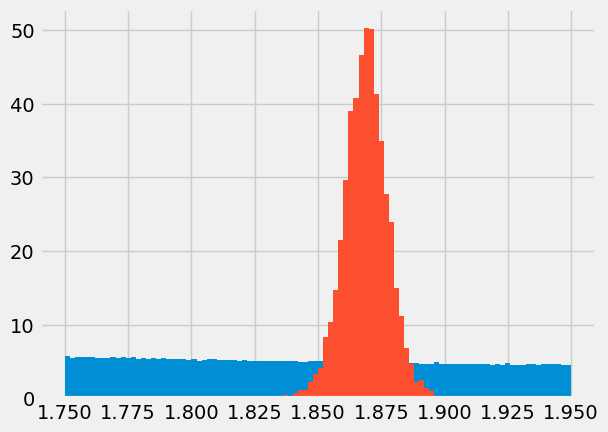

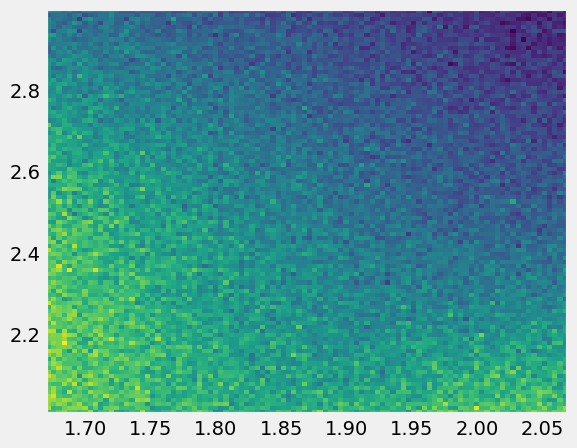

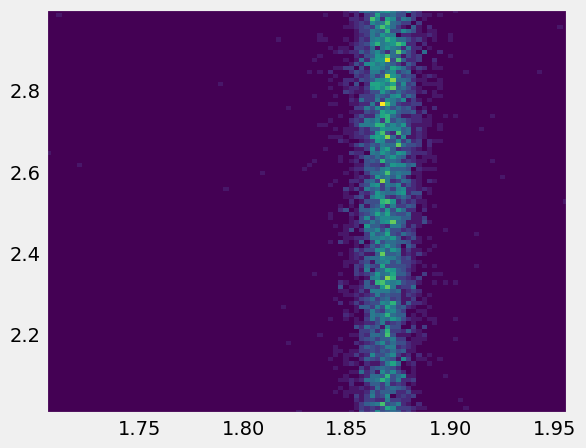

In [222]:
plt.hist(training_data_bkg['inv_mass'],range=[1.75,1.95],bins=100,density=True)
plt.hist(training_data_FD['inv_mass'],range=[1.75,1.95],bins=100,density=True)

fig, ax = plt.subplots(figsize=(6, 5))

# plt.hist([embedded1D,embedded1D_test],bins=100)
ax.hist2d(training_data_bkg['inv_mass'],training_data_bkg['pt_cand'],bins=[100,100])

plt.show()
fig, ax = plt.subplots(figsize=(6, 5))

# plt.hist([embedded1D,embedded1D_test],bins=100)
ax.hist2d(training_data_FD['inv_mass'],training_data_FD['pt_cand'],bins=[100,100])

plt.show()


In [223]:
# Definieer een auto encoder neural network. Dit type neural network bgint met de volledige 16 parameters, comprimeert ze in steeds kleinere lagen
# Totdat het de kleinste laag van maar twee neuronen bereikt. Daarna probeert het hiermee weer de originele parameters te recreeëren
# Dit model leert dus voor het signaal van D+ deeltjes hoe de data er ongeveer uitziet. Het verschil tussen de input en output parameters
# Voor D+ deeltjes zou dus heel klein moeten zijn, en de error dus klein. Maar het model is niet getrained op alle andere deeltjes.
# De verwachting is dus dat andere deeltjes die geen D+ deeltjes zijn, de autoencoder heel slecht zal zijn in de parameters recreeëren zonder extra training.
# Zo kan de error van het netwerk gebruikt worden als classificatie van wel of niet D+ deeltjes.

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()   # let PyTorch do its initialization first

        self.shrinking = nn.Sequential(
            nn.Linear(16, 12),
            nn.Sigmoid(),
            nn.Linear(12, 8),
            nn.Sigmoid(),
            # nn.Linear(8, 4),
            # nn.Sigmoid(),
            # nn.Linear(4, 2),
            # nn.Sigmoid(),
        )
        self.growing = nn.Sequential(
            # nn.Linear(2, 4),
            # nn.Sigmoid(),
            # nn.Linear(4, 8),
            nn.Sigmoid(),
            nn.Linear(8, 12),
            nn.Sigmoid(),
            nn.Linear(12, 16),
        )

    def forward(self, features):
        return self.growing(self.shrinking(features))

class Autoencoder4D(nn.Module):
    def __init__(self):
        super().__init__()

        self.shrinking = nn.Sequential(
            nn.Linear(16, 2),
            nn.ReLU(),
            # nn.Linear(12, 8),
            # nn.ReLU(),
            # nn.Linear(8, 4),
            # nn.ReLU(),
            # nn.Linear(4, 2),
            # nn.Sigmoid(),
        )
        self.growing = nn.Sequential(
            # nn.Linear(2, 4),
            # nn.Sigmoid(),
            # nn.Linear(4, 8),
            # nn.ReLU(),
            # nn.Linear(8, 12),
            # nn.ReLU(),
            nn.Linear(2, 16),
        )

    def forward(self, x):
        return self.growing(self.shrinking(x))

class Autoencoder2D(nn.Module):
    def __init__(self):
        super().__init__()

        self.shrinking = nn.Sequential(
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 2),
            nn.Sigmoid(),
        )
        self.growing = nn.Sequential(
            nn.Linear(2, 4),
            nn.Sigmoid(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 12),
            nn.ReLU(),
            nn.Linear(12, 16),
        )

    def forward(self, x):
        return self.growing(self.shrinking(x))
    
class Autoencoder1D(nn.Module):
    def __init__(self):
        super().__init__()

        self.shrinking = nn.Sequential(
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 2),
            nn.Sigmoid(),
            nn.Linear(2, 1),
            nn.Sigmoid(),
        )
        self.growing = nn.Sequential(
            nn.Linear(1, 2),
            nn.Sigmoid(),
            nn.Linear(2, 4),
            nn.Sigmoid(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 12),
            nn.ReLU(),
            nn.Linear(12, 16),
        )

    def forward(self, x):
        return self.growing(self.shrinking(x))


Epoch 1/2000, Loss: 3.356266
Epoch 2/2000, Loss: 3.318401
Epoch 3/2000, Loss: 3.284510
Epoch 4/2000, Loss: 3.250610
Epoch 5/2000, Loss: 3.219915
Epoch 6/2000, Loss: 3.202559
Epoch 7/2000, Loss: 3.174733
Epoch 8/2000, Loss: 3.156991
Epoch 9/2000, Loss: 3.138489
Epoch 10/2000, Loss: 3.117812
Epoch 11/2000, Loss: 3.109909
Epoch 12/2000, Loss: 3.099268
Epoch 13/2000, Loss: 3.089246
Epoch 14/2000, Loss: 3.072852
Epoch 15/2000, Loss: 3.069511
Epoch 16/2000, Loss: 3.064483
Epoch 17/2000, Loss: 3.053201
Epoch 18/2000, Loss: 3.051626
Epoch 19/2000, Loss: 3.044831
Epoch 20/2000, Loss: 3.038920
Epoch 21/2000, Loss: 3.036009
Epoch 22/2000, Loss: 3.031638
Epoch 23/2000, Loss: 3.028817
Epoch 24/2000, Loss: 3.026981
Epoch 25/2000, Loss: 3.026603
Epoch 26/2000, Loss: 3.019064
Epoch 27/2000, Loss: 3.020102
Epoch 28/2000, Loss: 3.014189
Epoch 29/2000, Loss: 3.017250
Epoch 30/2000, Loss: 3.012327
Epoch 31/2000, Loss: 3.004418
Epoch 32/2000, Loss: 3.013077
Epoch 33/2000, Loss: 3.007690
Epoch 34/2000, Loss

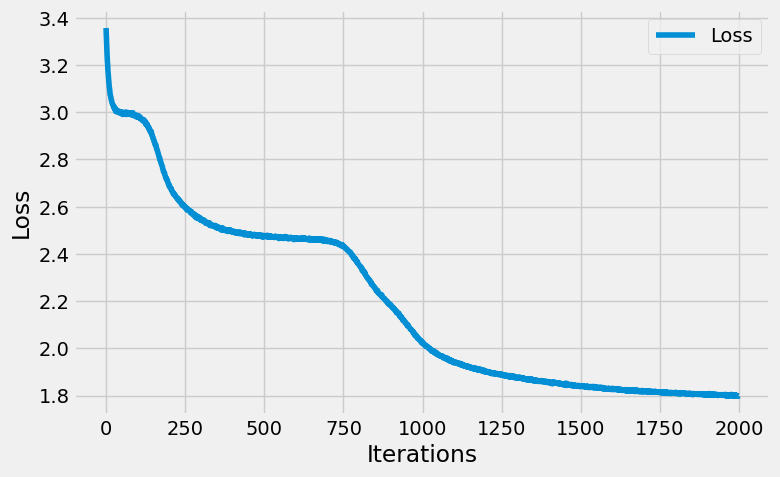

In [224]:
model_8D = Autoencoder()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model_8D.parameters(), lr=1e-3, weight_decay=1e-8)
epochs = 2000
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_8D.to(device)
loss_vs_epoch = []
for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        features = batch[0].to(device)
        
        reconstructed = model_8D(features)
        loss = loss_function(reconstructed, features)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    loss_vs_epoch.append(total_loss)
    outputs.append((epoch, features, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(loss_vs_epoch, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/2000, Loss: 3.690537
Epoch 2/2000, Loss: 3.665431
Epoch 3/2000, Loss: 3.640470
Epoch 4/2000, Loss: 3.618592
Epoch 5/2000, Loss: 3.602249
Epoch 6/2000, Loss: 3.583035
Epoch 7/2000, Loss: 3.563749
Epoch 8/2000, Loss: 3.546744
Epoch 9/2000, Loss: 3.528537
Epoch 10/2000, Loss: 3.512212
Epoch 11/2000, Loss: 3.497848
Epoch 12/2000, Loss: 3.482369
Epoch 13/2000, Loss: 3.464999
Epoch 14/2000, Loss: 3.450217
Epoch 15/2000, Loss: 3.436561
Epoch 16/2000, Loss: 3.424185
Epoch 17/2000, Loss: 3.408280
Epoch 18/2000, Loss: 3.391601
Epoch 19/2000, Loss: 3.384088
Epoch 20/2000, Loss: 3.369581
Epoch 21/2000, Loss: 3.356236
Epoch 22/2000, Loss: 3.350090
Epoch 23/2000, Loss: 3.333133
Epoch 24/2000, Loss: 3.322166
Epoch 25/2000, Loss: 3.305569
Epoch 26/2000, Loss: 3.301061
Epoch 27/2000, Loss: 3.286293
Epoch 28/2000, Loss: 3.276575
Epoch 29/2000, Loss: 3.264245
Epoch 30/2000, Loss: 3.256341
Epoch 31/2000, Loss: 3.243644
Epoch 32/2000, Loss: 3.229702
Epoch 33/2000, Loss: 3.220562
Epoch 34/2000, Loss

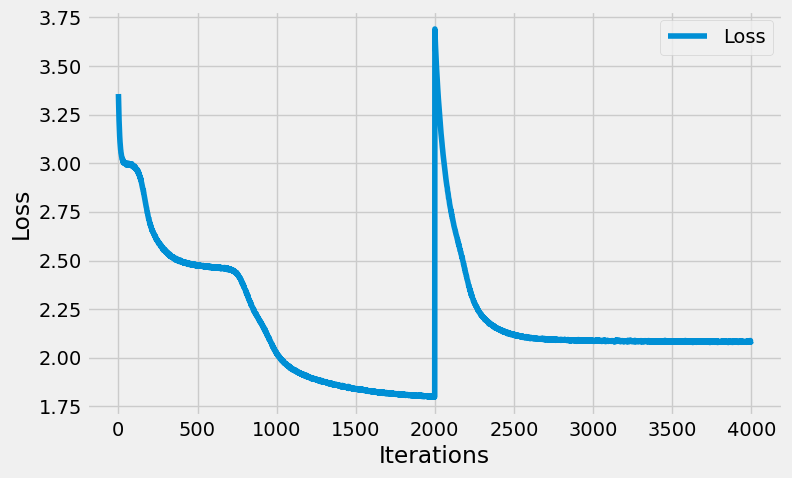

In [225]:
# Initialize a new model with smallest inner layer dimension 4 to train
model_4D = Autoencoder4D()
old_state = model_8D.state_dict()
new_state = model_4D.state_dict()

# copy matching parameters
for name, param in old_state.items():
    if name in new_state and new_state[name].shape == param.shape:
        new_state[name] = param

model_4D.load_state_dict(new_state)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_4D.to(device)
optimizer = optim.Adam(model_4D.parameters(), lr=1e-3, weight_decay=1e-8)

for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        features = batch[0].to(device)
        
        reconstructed = model_4D(features)
        loss = loss_function(reconstructed, features)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    loss_vs_epoch.append(total_loss)
    outputs.append((epoch, features, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")
    
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(loss_vs_epoch, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

Average reconstruction error new: 0.659792
Average reconstruction error training: 0.599686


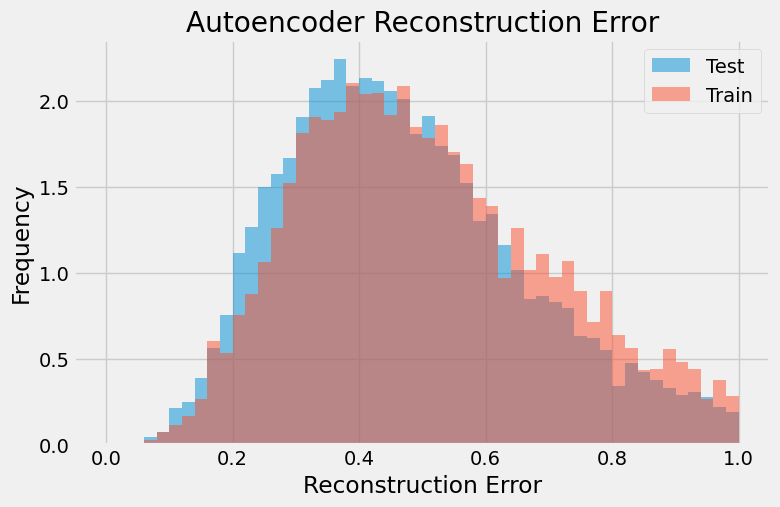

In [226]:
# Find the error of the values in the dataset
def compute_sample_errors(model, loader, device='cpu'):
    model.eval()
    model.to(device)

    errors = []

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device).float()

            recon = model(x)

            # MSE per sample
            # reduction='none' gives shape [batch, features]
            sample_loss = torch.mean((x - recon)**2, dim=1)

            errors.extend(sample_loss.cpu().numpy())

    return np.array(errors)

# Find the error in reconstructing the parameters. Should be large for parameters dissimilar to what we trained.
def compute_average_reconstruction_error(model, loader, device='cpu'):
    model.eval()
    model.to(device)
    total_loss = 0.0
    n_samples = 0

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device).float()   # ensure dtype matches model
            recon = model(x)
            batch_loss = torch.mean((x - recon)**2, dim=1)  # per-sample MSE
            total_loss += batch_loss.sum().item()
            n_samples += x.size(0)

    avg_loss = total_loss / n_samples
    return avg_loss


avg_error = compute_average_reconstruction_error(model_8D, loader_test)
print(f"Average reconstruction error new: {avg_error:.6f}")
avg_error = compute_average_reconstruction_error(model_8D, loader)
print(f"Average reconstruction error training: {avg_error:.6f}")

errors = [compute_sample_errors(model_8D, loader_test),compute_sample_errors(model_8D, loader)]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(errors[0], bins=50, range=[0,1], alpha=0.5, label='Test', density=True)
plt.hist(errors[1], bins=50, range=[0,1], alpha=0.5, label='Train', density=True)
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Autoencoder Reconstruction Error")
plt.legend()
plt.show()


(array([0.02852253, 1.03365659, 0.58071877, 0.1756988 , 0.07872219,
        0.04221335, 0.02281803, 0.01483172, 0.01140901, 0.01140901]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

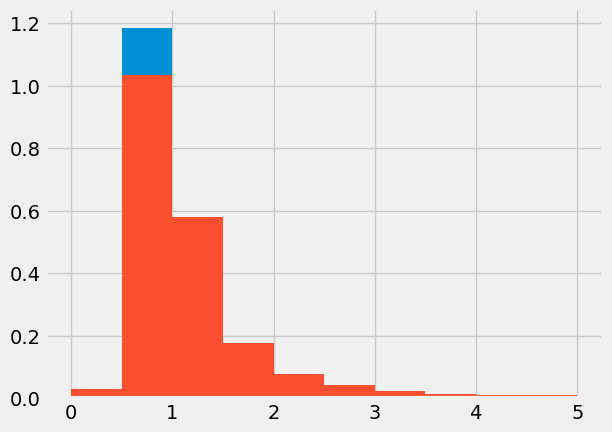

In [227]:
model_1D.eval()
with torch.no_grad():
    latent_normal = model_1D.shrinking(features.to(device).float()).cpu().numpy()  # latent codes

from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(latent_normal)  

model_1D.eval()
with torch.no_grad():
    latent_test = model_1D.shrinking(features_test.to(device).float()).cpu().numpy()
    latent = model_1D.shrinking(features.to(device).float()).cpu().numpy()

log_density = kde.score_samples(latent_test)  # evaluate density of test points
log_density_labeled = kde.score_samples(latent)  # evaluate density of test points

with torch.no_grad():
    recon_test = model_1D(features_test.to(device).float())
    recon_error = torch.mean((features_test.to(device).float() - recon_test)**2, dim=1).cpu().numpy()
    recon = model_1D(features.to(device).float())
    recon_error_labeled = torch.mean((features.to(device).float() - recon)**2, dim=1).cpu().numpy()

anomaly_score = recon_error - log_density
anomaly_score_labeled = recon_error_labeled - log_density_labeled
plt.hist(anomaly_score,range=[0,5],density=True)
plt.hist(anomaly_score_labeled,range=[0,5],density=True)

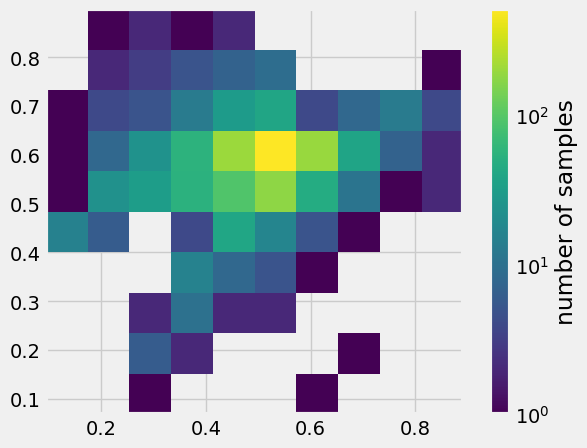

C:\Users\sande\AppData\Local\Temp\ipykernel_20636\1929032935.py:27: UserWarning: Adding colorbar to a different Figure <Figure size 600x500 with 2 Axes> than <Figure size 600x500 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(p[-1], ax=ax, label="number of samples")


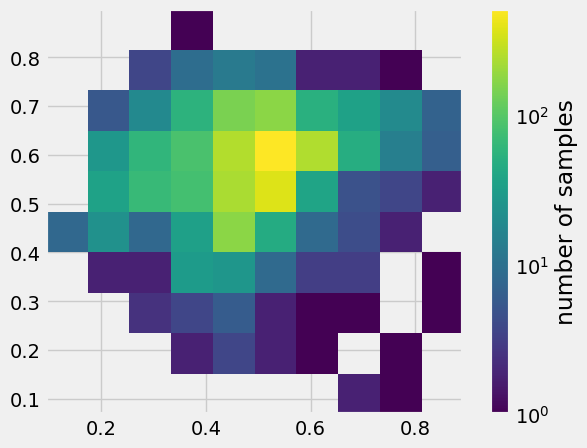

In [228]:
embedded1D = model_1D.shrinking(features).detach().numpy()[:, 0]
embedded1D_test = model_1D.shrinking(features_test).detach().numpy()[:, 0]

embedded = model_2D.shrinking(features).detach().numpy()
embedded_test = model_2D.shrinking(features_test).detach().numpy()
fig, ax = plt.subplots(figsize=(6, 5))

xmin, xmax = np.min(embedded[:, 0]), np.max(embedded[:, 0])
ymin, ymax = np.min(embedded[:, 1]), np.max(embedded[:, 1])

def plot_embedded(ax, embedded):    
    p = ax.hist2d(embedded[:, 0], embedded[:, 1],
                  bins=(10, 10), range=((xmin, xmax), (ymin, ymax)),
                  norm=mpl.colors.LogNorm())
    ax.axis([xmin, xmax, ymin, ymax])
    return p

# plt.hist([embedded1D,embedded1D_test],bins=100)
p = plot_embedded(ax, embedded)

fig.colorbar(p[-1], ax=ax, label="number of samples")
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))
p2 = plot_embedded(ax,embedded_test)
fig.colorbar(p[-1], ax=ax, label="number of samples")

plt.show()

In [229]:
from sklearn.neighbors import KernelDensity


model = model_2D
# Encode all normal training data
model.eval()
with torch.no_grad():
    latent = model.shrinking(features.to(device).float()).cpu().numpy()

kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(latent)

def anomaly_score(model, x, kde, device='cpu'):
    model.eval()
    x = x.to(device).float()
    with torch.no_grad():
        latent = model.shrinking(x).cpu().numpy()
        recon = model(x)
        recon_error = torch.mean((x - recon)**2, dim=1).cpu().numpy()
        latent_density = kde.score_samples(latent)  # log-likelihood
    # High error + low density → anomaly
    score = recon_error - latent_density  # you can weight them differently
    return score

# normal_data: Tensor, outlier_data: Tensor
scores_normal = anomaly_score(model, features_test, kde)
scores_outlier = anomaly_score(model, features, kde)

# Choose threshold that maximizes F1 or TPR/FPR tradeoff
from sklearn.metrics import roc_auc_score, precision_recall_curve

y_true = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_outlier))])
y_scores = np.concatenate([scores_normal, scores_outlier])

roc_auc = roc_auc_score(y_true, y_scores)
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
print(roc_auc)


0.5255102708803612
